In [1]:
%load_ext autoreload

In [2]:
%autoreload 1

In [3]:
import os, re, sys
import logging
import numpy as np
from rich import print
from rich.pretty import pprint
from rich.progress import track
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib.backends.backend_pdf import PdfPages
import hist
from hist import Hist
import mplhep as hep
import uproot
from rich.progress import Progress

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import cms_styles

%aimport plot_utils

In [4]:
mpl.rcParams.update({"figure.max_open_warning": 0})
hep.style.use("CMS")
np.set_printoptions(suppress=True)

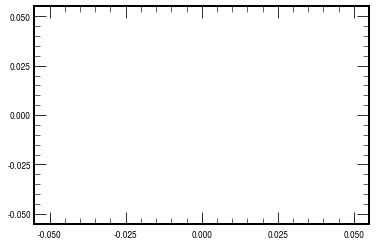

In [5]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"
plt.style.use(cms_styles.CMS_petroff_10)

In [6]:
logging.getLogger().setLevel(logging.ERROR)

In [7]:
def merge_runs(plots, run):
    names = [
        "Higgs",
        "TTV",
        "ST_NLO",
        "WJets",
        "VV+VVV",
        "TT_powheg",
        "DY",
        "QCD_Pt_MuEnrichedPt5",
        "total_bkg",
    ]
    # Add signal processes
    signal_processes = list(
        set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13TeV", p))
    )
    # Remove 2016APV for now
    # years = ["2016APV", "2016", "2017", "2018"]
    years = ["2016", "2017", "2018"]
    if run == "Run3":
        names.remove("TTV")
        names.remove("ST_NLO")
        years = ["2022", "2022EE", "2023", "2023BPix"]
        # Add signal processes
        signal_processes = list(
            set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13p6TeV", p))
        )
    names.append("Data")
    names.extend(signal_processes)
    run_plots = {}
    for name in names:
        run_plots[f"{name}_{run}"] = {}
        for year in years:
            if f"{name}_{year}" not in plots.keys():
                continue
            for plot in plots[f"{name}_{year}"]:
                if plot not in run_plots[f"{name}_{run}"].keys():
                    run_plots[f"{name}_{run}"][plot] = plots[f"{name}_{year}"][
                        plot
                    ].copy()
                else:
                    run_plots[f"{name}_{run}"][plot] += plots[f"{name}_{year}"][plot]
    return run_plots

In [24]:
plots = {}
years_to_load = [
    # "2016APV",
    # "2016",
    # "2017",
    "2018",
    # "2022",
    # "2022EE",
    # "2023",
    # "2023BPix",
]
for year in track(years_to_load, description="Loading plots"):
    plots = plots | plot_utils.loader(
        tag=f"mass_spectrum_Sep2025_{year}",
        era=year,
        load_data=True,
    )
# run2_plots = merge_runs(plots, "Run2")
# plots = plots | run2_plots
# run3_plots = merge_runs(plots, "Run3")
# plots = plots | run3_plots

Loading plots ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00
Loading plots ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00

In [25]:
plots["QCD_Pt_MuEnrichedPt5_2018"]["SR_high_temp_loose_dimuon_mass"]

Hist(
  Regular(100, 0.1, 200, transform=log, name='SR_high_temp_loose_dimuon_mass'),
  Regular(5, 3, 8, name='nMuon'),
  storage=Weight()) # Sum: WeightedSum(value=5.74822e+07, variance=1.54366e+11) (WeightedSum(value=5.74849e+07, variance=1.54366e+11) with flow)

CR_prompt_dimuon_mass, nMuon=2

/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:208: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 10*y_max_lin)


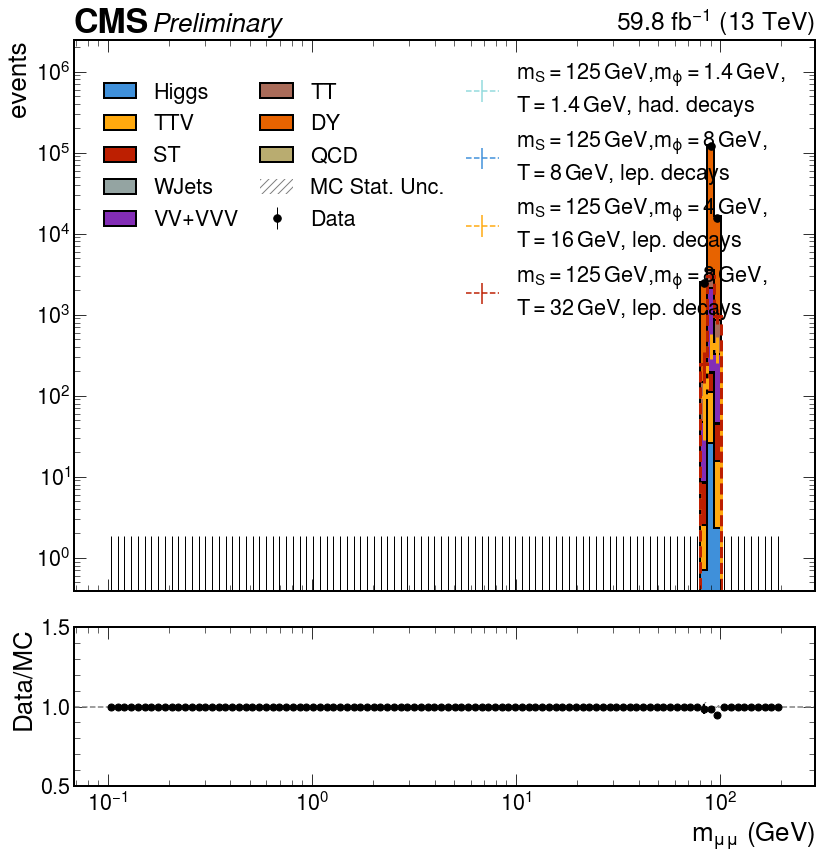

CR_prompt_dimuon_mass, nMuon=3

/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:208: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 10*y_max_lin)


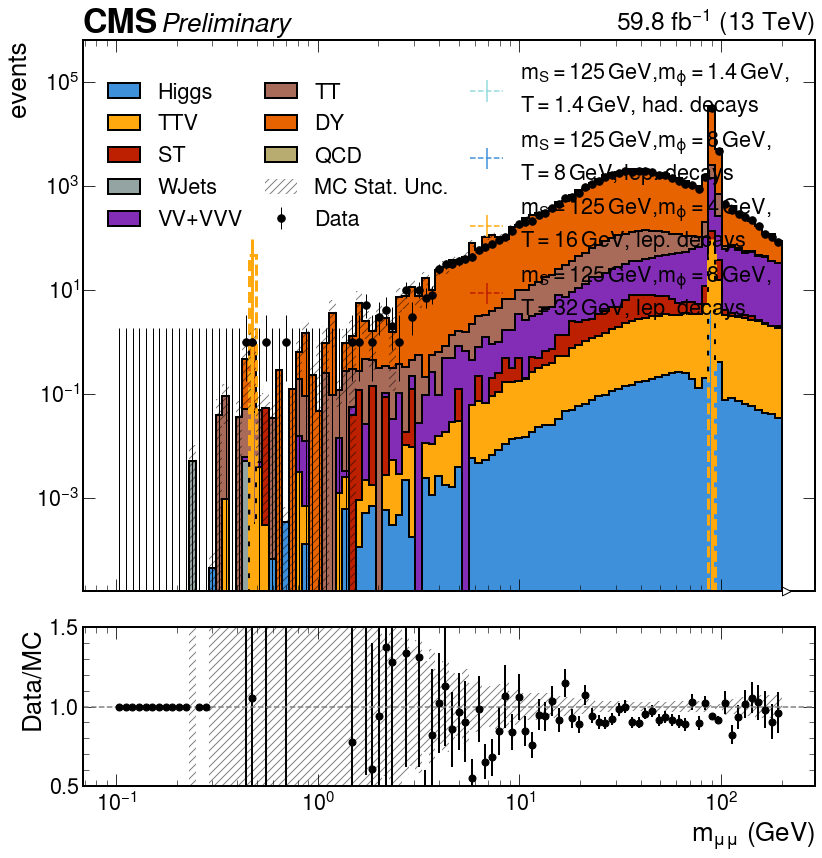

CR_prompt_dimuon_mass, nMuon=4

/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:208: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 10*y_max_lin)


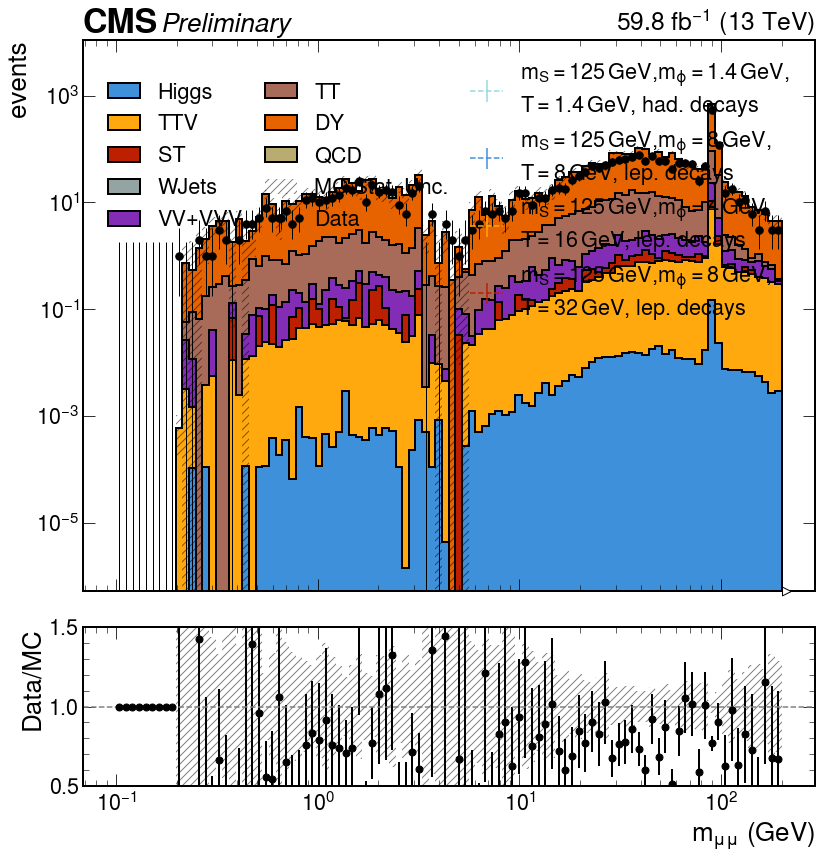

CR_prompt_dimuon_mass, nMuon=5

/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:208: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 10*y_max_lin)


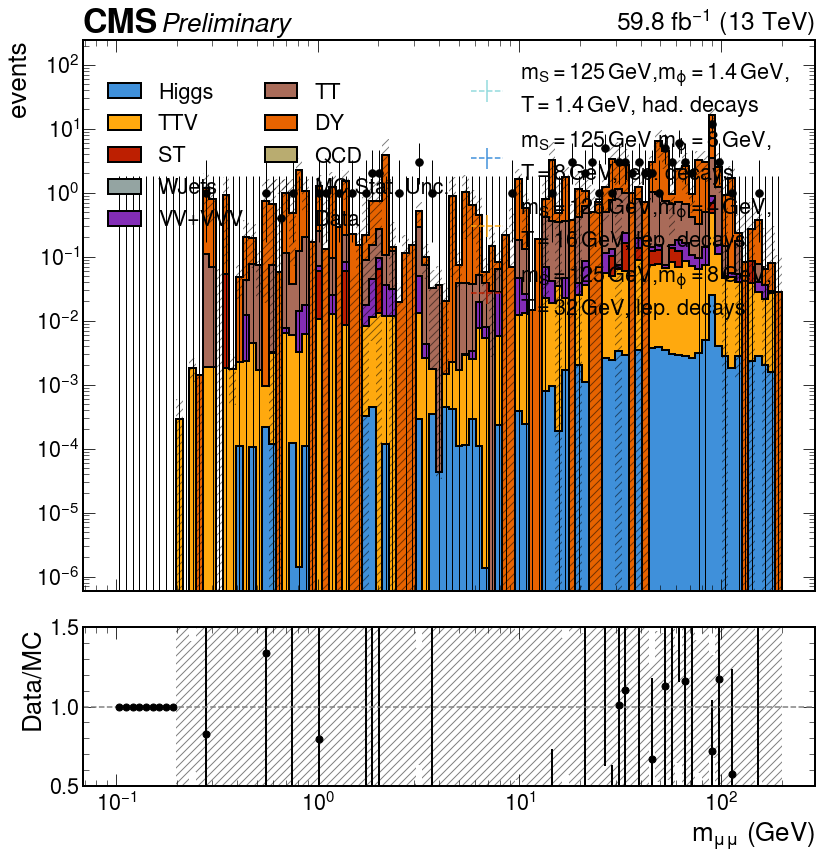

CR_cb_dimuon_mass, nMuon=2

/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


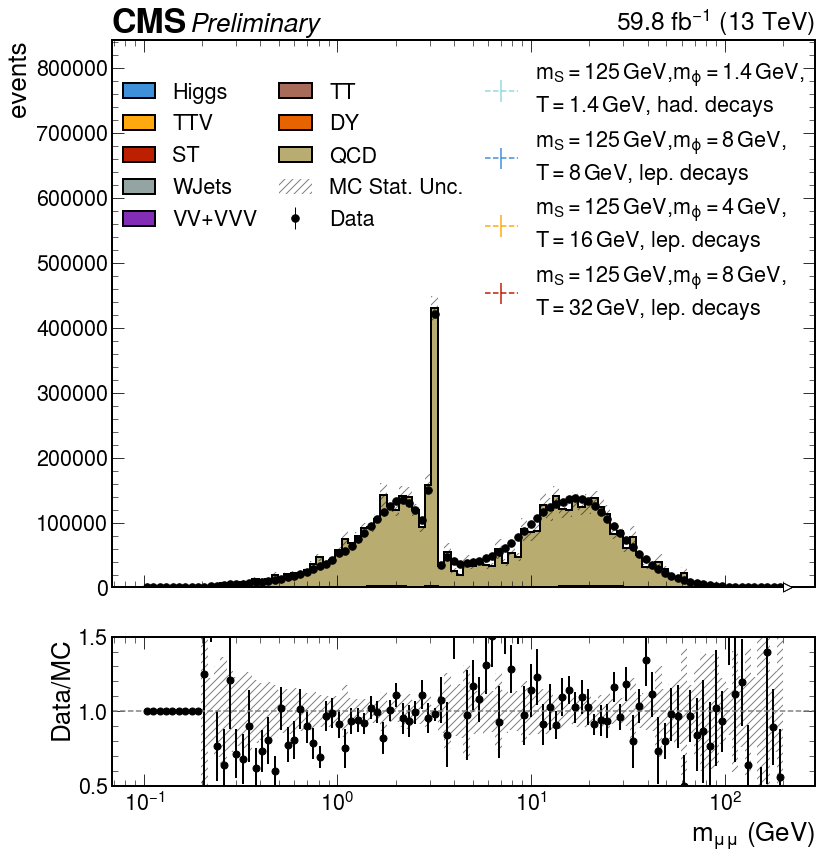

CR_cb_dimuon_mass, nMuon=3

/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


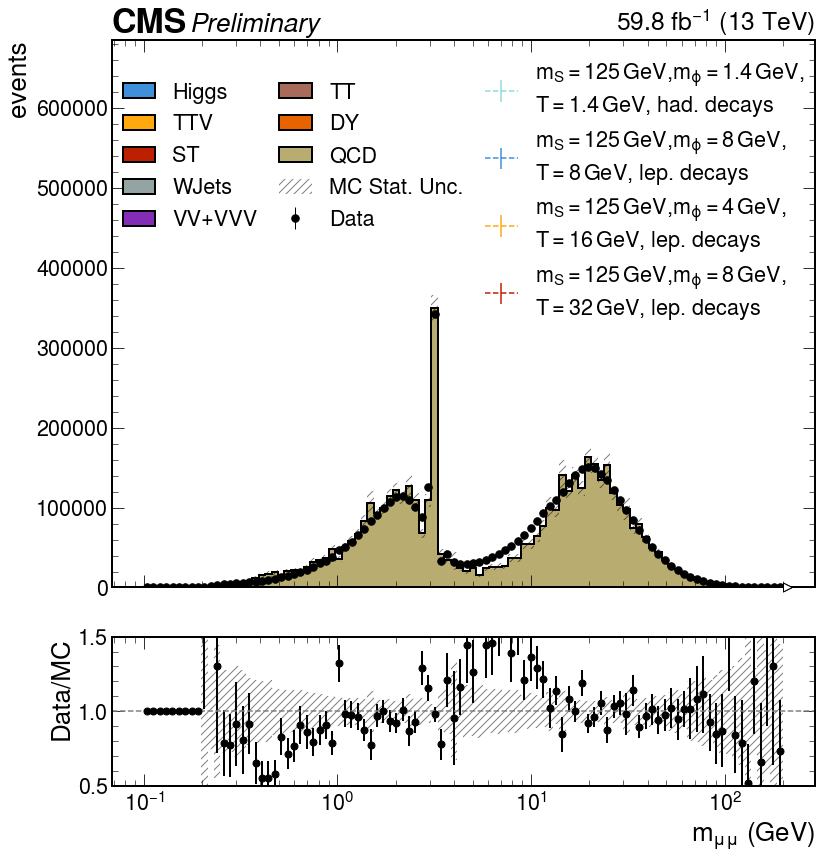

CR_cb_dimuon_mass, nMuon=4

/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:62: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/3002223397.py:63: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


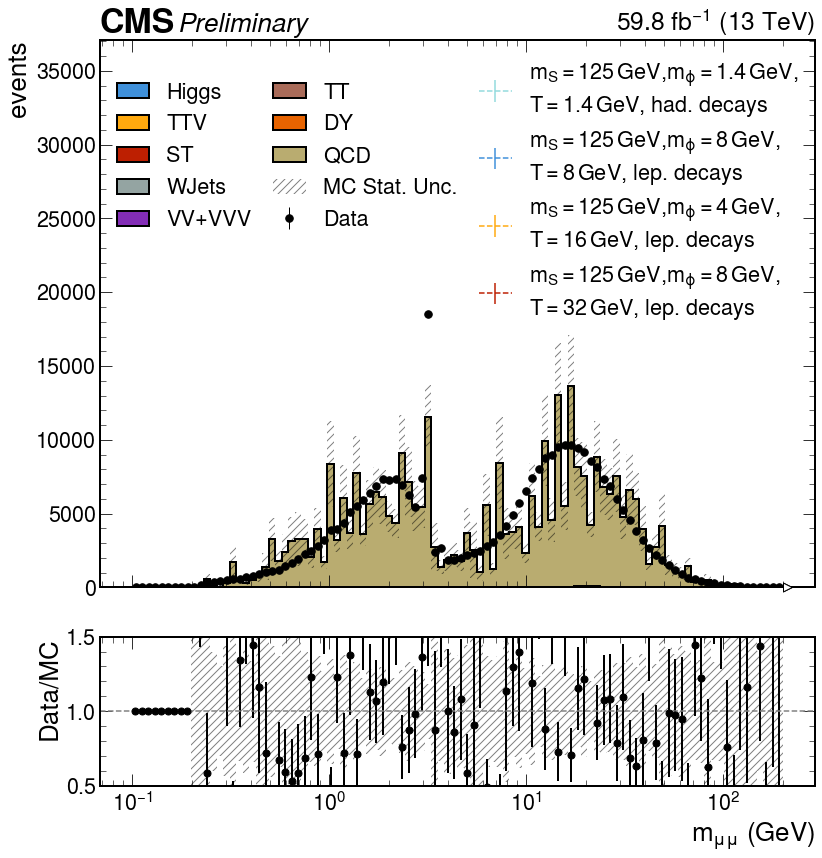

In [27]:
mc_processes = [
    ("Higgs_2018", "Higgs"),
    ("TTV_2018", "TTV"),
    ("ST_NLO_2018", "ST"),
    ("WJets_2018", "WJets"),
    ("VV+VVV_2018", "VV+VVV"),
    ("TT_powheg_2018", "TT"),
    ("DY_2018", "DY"),
    ("QCD_Pt_MuEnrichedPt5_2018", "QCD"),
]

signal_processes = [
    "GluGluToSUEP_mS125.000_mPhi1.400_T1.400_modehadronic_13TeV_2018",
    "GluGluToSUEP_mS125.000_mPhi8.000_T8.000_modeleptonic_13TeV_2018",
    "GluGluToSUEP_mS125.000_mPhi4.000_T16.000_modeleptonic_13TeV_2018",
    "GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018",
]
signal_labels = [
    r"$m_S=125\,$GeV,$m_\phi=1.4\,$GeV," + "\n" + r"$T=1.4\,$GeV, had. decays",
    r"$m_S=125\,$GeV,$m_\phi=8\,$GeV," + "\n" + r"$T=8\,$GeV, lep. decays",
    r"$m_S=125\,$GeV,$m_\phi=4\,$GeV," + "\n" + r"$T=16\,$GeV, lep. decays",
    r"$m_S=125\,$GeV,$m_\phi=8\,$GeV," + "\n" + r"$T=32\,$GeV, lep. decays",
]

mass_range = slice(0.1j, 200j)


def calculate_k_factor(
    plots,
    plot,
    cut=(slice(None), slice(None)),
    year="2018",
    process="QCD_Pt_MuEnrichedPt5",
):
    mc_processes = [
        "Higgs",
        "TTV",
        "ST_NLO",
        "WJets",
        "VV+VVV",
        "TT_powheg",
        "DY",
        "QCD_Pt_MuEnrichedPt5",
    ]

    if plots[f"{process}_{year}"][plot][cut].sum().value == 0:
        return 1

    tot_bkg = plots[f"{process}_{year}"][plot][cut].copy().reset()
    for mc_proc in mc_processes:
        if process == mc_proc:
            continue
        tot_bkg += plots[f"{mc_proc}_{year}"][plot][cut]
    k_factor = (
        plots["Data_" + year][plot][cut].sum().value - tot_bkg.sum().value
    ) / plots[f"{process}_{year}"][plot][cut].sum().value
    return k_factor


def plot_ratio(hist_data, hist_bkg_total, ax, x_hatch):
    ratio = np.divide(
        hist_data.values(),
        hist_bkg_total.values(),
        out=np.ones_like(hist_data.values()),
        where=hist_bkg_total.values() != 0,
    )
    ratio_err = np.where(
        hist_bkg_total.values() > 0,
        np.sqrt(
            (hist_bkg_total.values() ** -2) * (hist_data.variances())
            + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
            * (hist_bkg_total.variances())
        ),
        0,
    )
    ax.errorbar(
        hist_data.axes.centers[0],
        ratio,
        yerr=ratio_err,
        color="black",
        fmt="o",
        linestyle="none",
        markersize=7,
        lw=2,
    )

    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
    mc_rel_unc = np.divide(
        np.sqrt(hist_bkg_total.variances()),
        hist_bkg_total.values(),
        out=np.zeros_like(hist_bkg_total.values()),
        where=hist_bkg_total.values() != 0,
    )
    y_hatch2 = np.vstack(
        (np.ones_like(hist_bkg_total.values()), np.ones_like(hist_bkg_total.values()))
    ).reshape((-1,), order="F")
    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
    ax.fill_between(
        x=x_hatch,
        y1=y_hatch2 - y_hatch2_unc,
        y2=y_hatch2 + y_hatch2_unc,
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
    )
    ax.axhline(1, ls="--", color="gray")


for region in ["CR_prompt", "CR_cb"]:
    for nMuon in range(2, 6):
        if region == "CR_cb" and nMuon == 5:
            continue
        k_factor = calculate_k_factor(
            plots, f"{region}_dimuon_mass", cut=(slice(13j, None), nMuon * 1j)
        )

        print(f"{region}_dimuon_mass, {nMuon=}")
        hists_mc = []
        hist_bkg_total = (
            plots["QCD_Pt_MuEnrichedPt5_2018"][f"{region}_dimuon_mass"][
                mass_range, nMuon * 1j
            ]
            .copy()
            .reset()
        )
        for process, label in mc_processes:
            h_mc = plots[process][f"{region}_dimuon_mass"][mass_range, nMuon * 1j]
            if process == "QCD_Pt_MuEnrichedPt5_2018":
                h_mc *= k_factor
            hists_mc.append(h_mc)
            hist_bkg_total += h_mc.copy()

        hists_signal = []
        for process in signal_processes:
            h_signal = plots[process][f"{region}_dimuon_mass"][mass_range, nMuon * 1j]
            hists_signal.append(h_signal)

        fig = plt.figure(figsize=(12, 12.5))
        plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
        ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
        ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

        hep.histplot(
            hists_mc,
            yerr=[np.sqrt(h.variances()) for h in hists_mc],
            stack=True,
            label=[p[1] for p in mc_processes],
            histtype="fill",
            ec="black",
            lw=2,
            ax=ax1,
        )

        hep.histplot(
            plots[f"Data_2018"][f"{region}_dimuon_mass"][mass_range, nMuon * 1j],
            label=["Data"],
            histtype="errorbar",
            mec="black",
            mfc="black",
            ecolor="black",
            markersize=15,
            lw=3,
            ax=ax1,
        )

        x_hatch = np.vstack(
            (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
        ).reshape((-1,), order="F")
        y_hatch1 = np.vstack(
            (hist_bkg_total.values(), hist_bkg_total.values())
        ).reshape((-1,), order="F")
        y_hatch1_unc = np.vstack(
            (np.sqrt(hist_bkg_total.variances()), np.sqrt(hist_bkg_total.variances()))
        ).reshape((-1,), order="F")
        ax1.fill_between(
            x=x_hatch,
            y1=y_hatch1 - y_hatch1_unc,  # type: ignore[assign]
            y2=y_hatch1 + y_hatch1_unc,  # type: ignore[assign]
            label="MC Stat. Unc.",
            step="pre",
            facecolor="none",
            edgecolor=(0, 0, 0, 0.5),
            linewidth=0,
            hatch="///",
            zorder=2,
        )
        hep.histplot(
            hists_signal,
            yerr=[np.sqrt(h.variances()) for h in hists_signal],
            label=[s for s in signal_labels],
            lw=3,
            ls="--",
            ax=ax1,
        )

        plot_ratio(
            plots[f"Data_{year}"][f"{region}_dimuon_mass"][mass_range, nMuon * 1j],
            hist_bkg_total,
            ax2,
            x_hatch,
        )

        hep.cms.label(llabel="Preliminary", data=True, lumi=59.8, ax=ax1)

        plt.sca(ax2)
        plt.xlabel(r"$m_{\mu\mu}$ (GeV)")
        plt.ylim(0.5, 1.5)
        plt.ylabel("Data/MC")
        plt.setp(ax1.get_xticklabels(), visible=False)
        ax1.set_xlabel("", visible=False)

        y_max_lin = 2 * max(
            plots[f"Data_{year}"][f"{region}_dimuon_mass"][
                mass_range, nMuon * 1j
            ].values()
        )

        plt.sca(ax1)
        # plt.xlim(1e-1, 1e2)
        plt.xscale("log")
        if region == "CR_prompt":
            plt.yscale("log")
            plt.ylim(0, 10 * y_max_lin)
        else:
            plt.ylim(0, y_max_lin)
        plt.legend(ncol=3, loc="upper center", columnspacing=1)
        plt.ylabel("events")
        plt.tight_layout()
        plt.show()

SR_low_temp_loose_dimuon_mass, nMuon=3

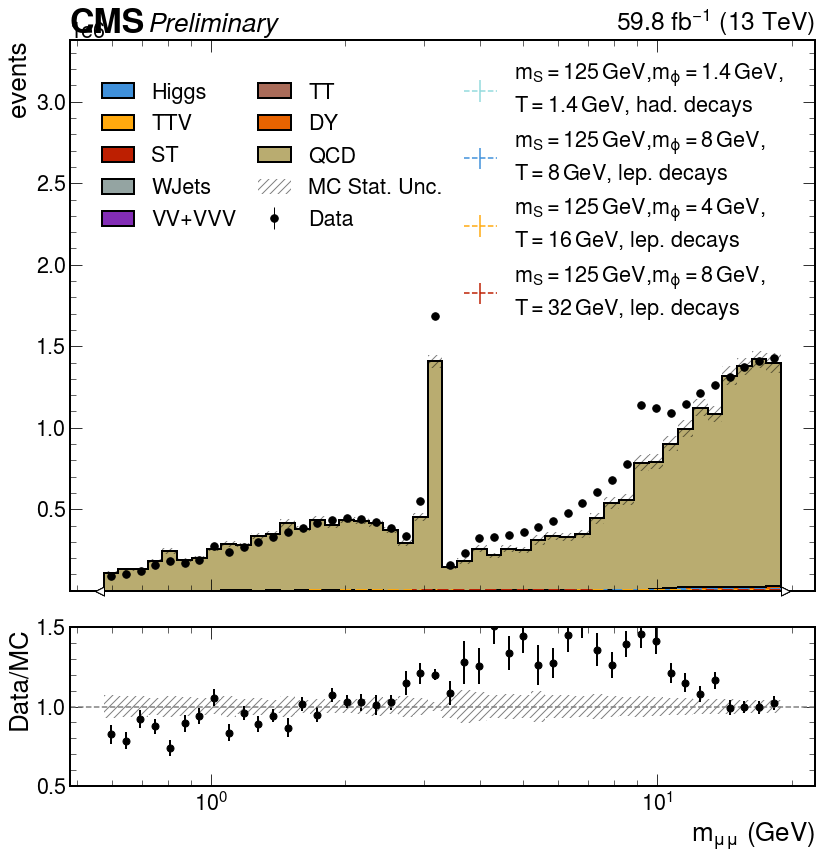

SR_low_temp_loose_dimuon_mass, nMuon=4

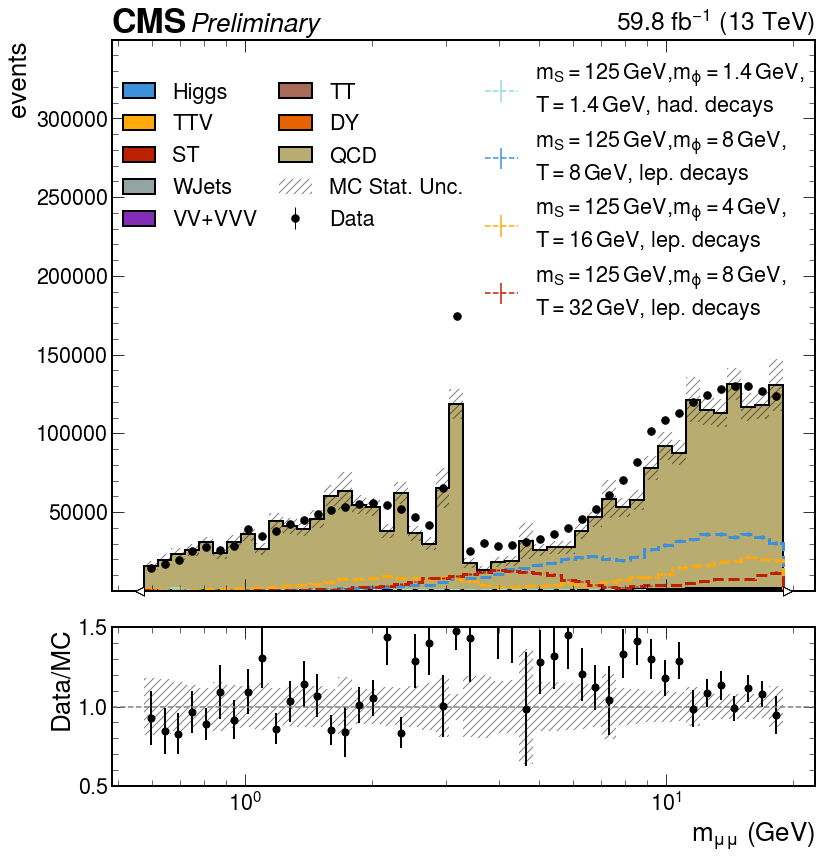

SR_low_temp_loose_dimuon_mass, nMuon=5

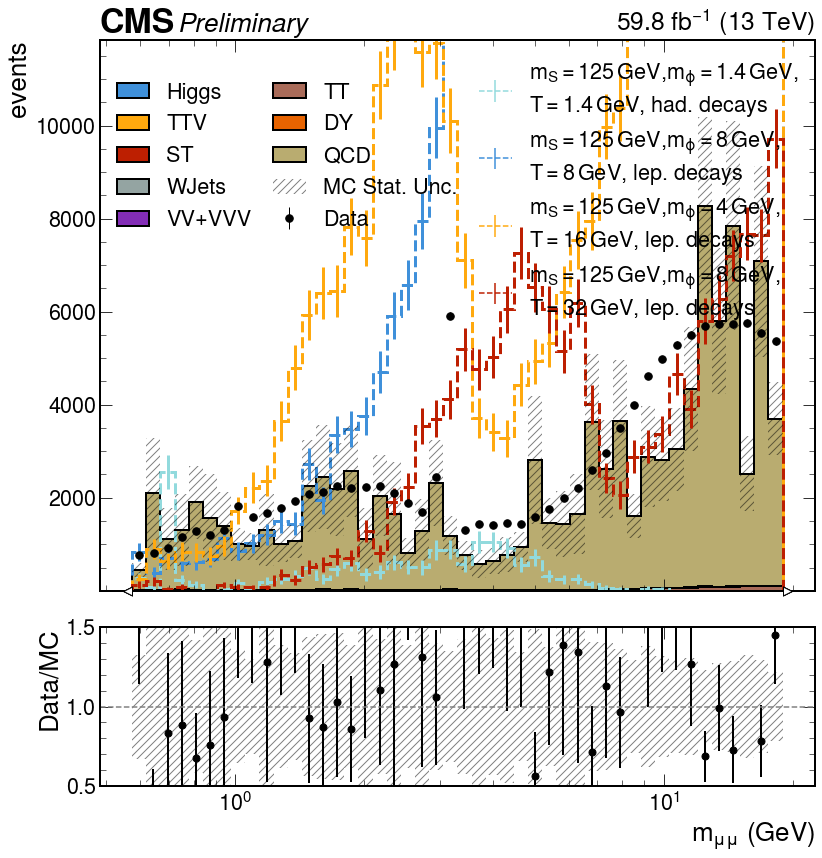

SR_low_temp_tight_dimuon_mass, nMuon=3

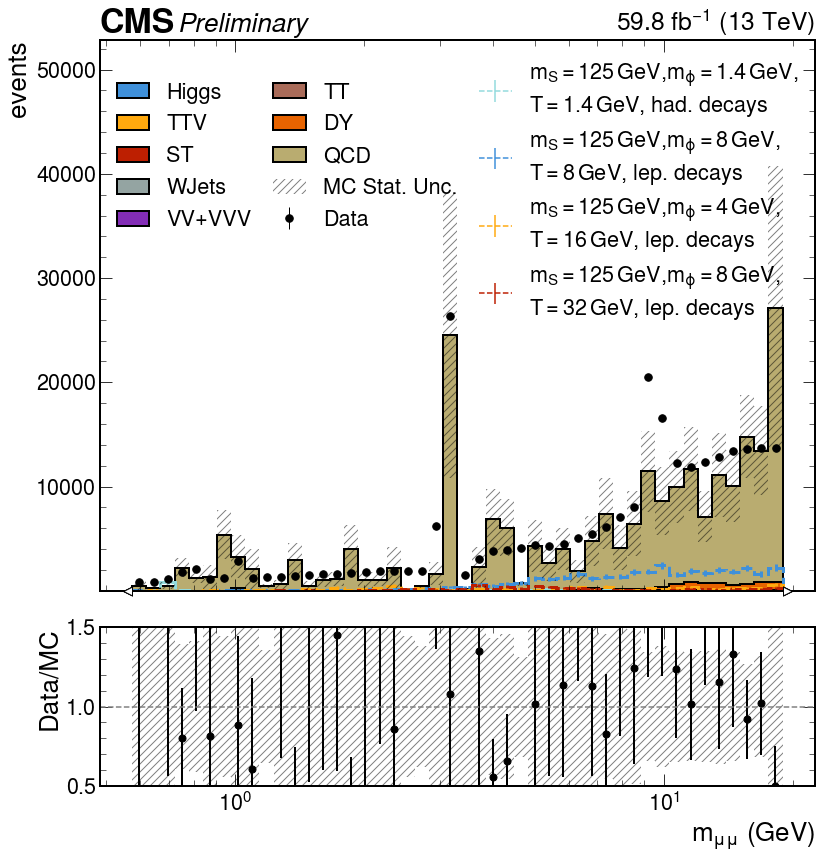

SR_low_temp_tight_dimuon_mass, nMuon=4

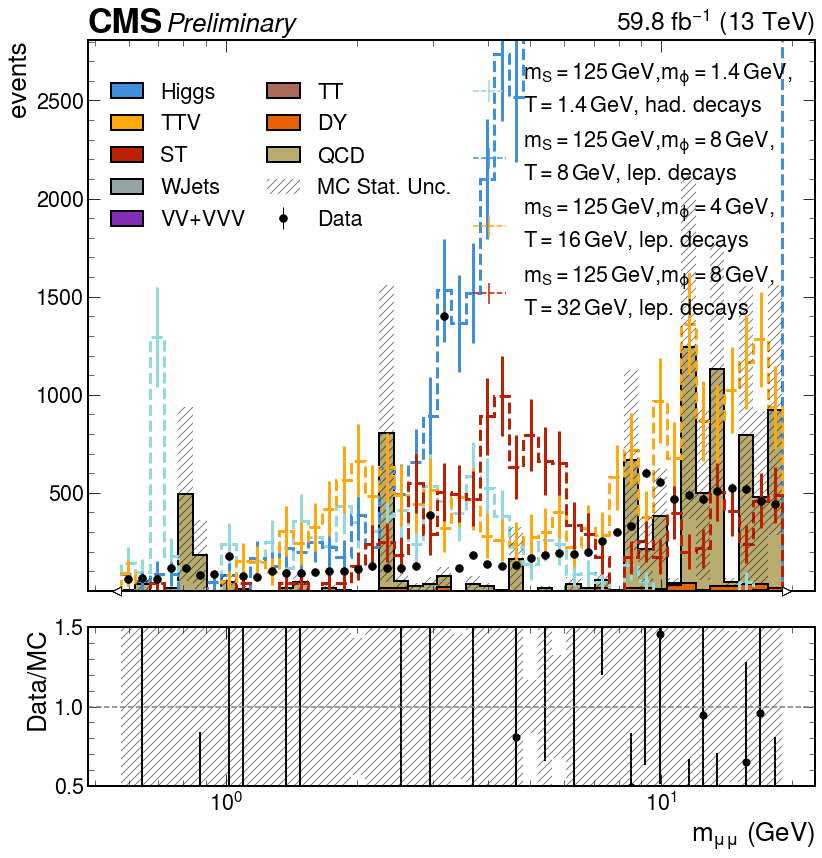

SR_low_temp_tight_dimuon_mass, nMuon=5

/tmp/ipykernel_82593/990882296.py:62: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/990882296.py:62: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_82593/990882296.py:63: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_82593/990882296.py:63: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


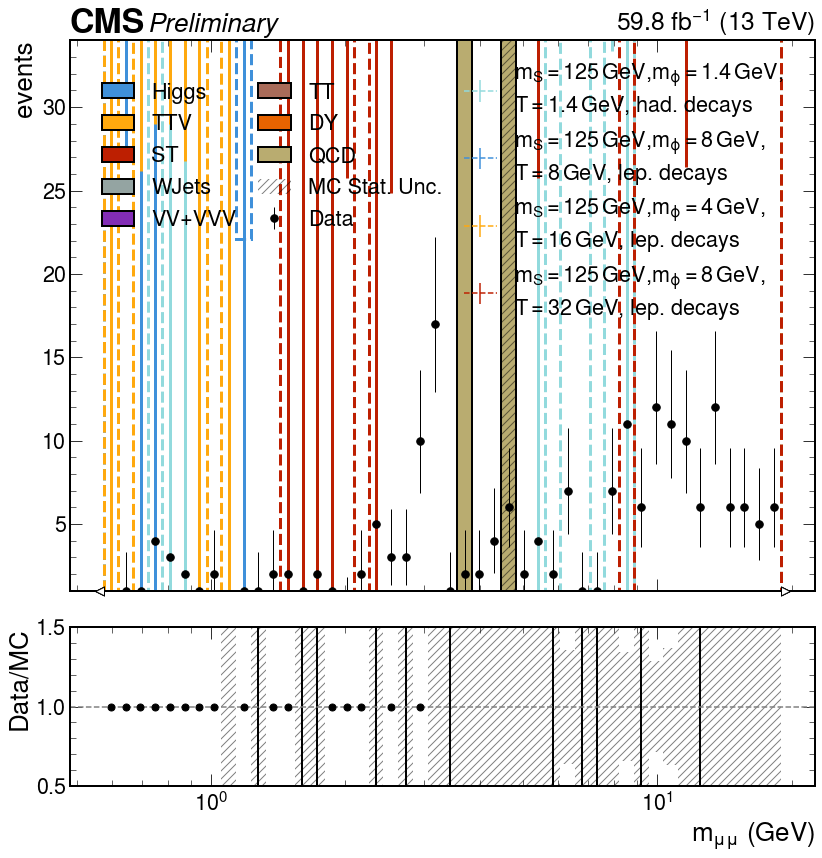

SR_high_temp_loose_dimuon_mass, nMuon=3

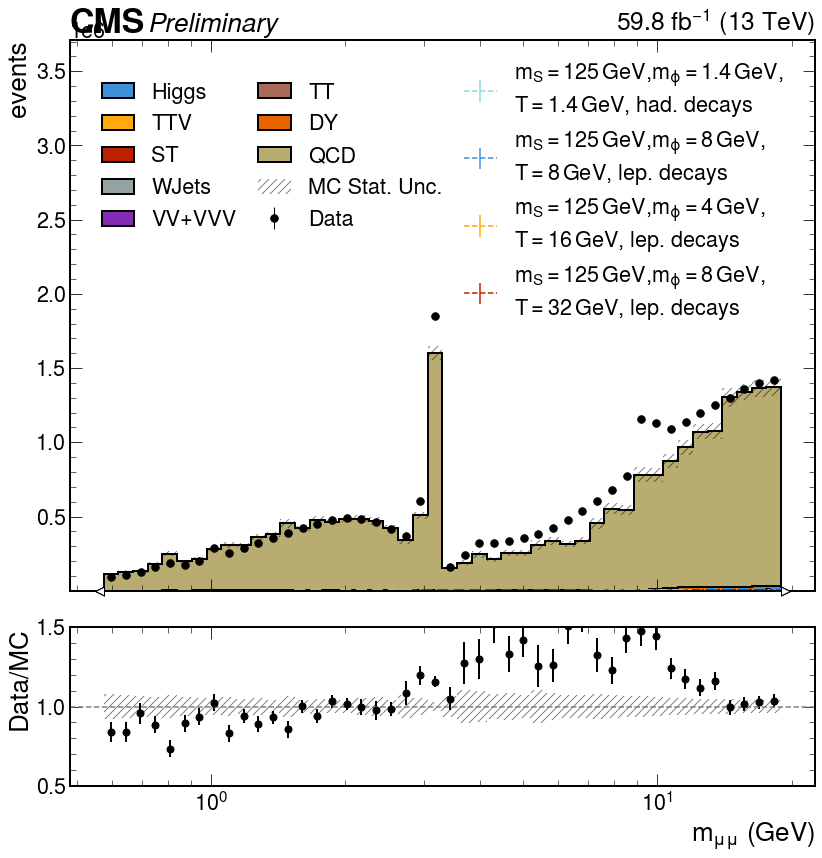

SR_high_temp_loose_dimuon_mass, nMuon=4

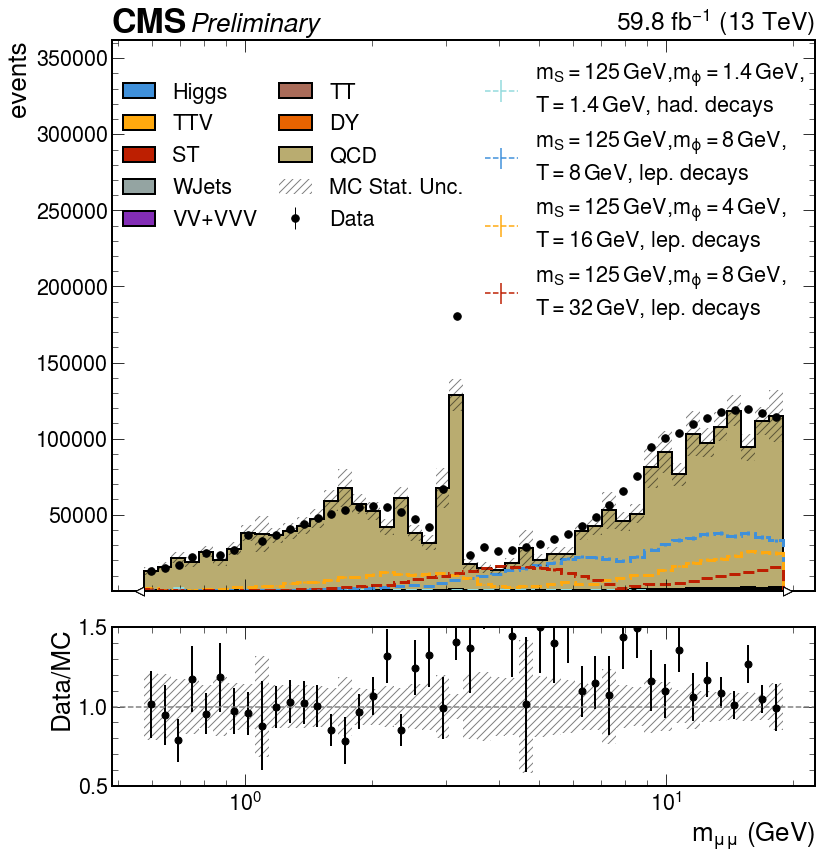

SR_high_temp_loose_dimuon_mass, nMuon=5

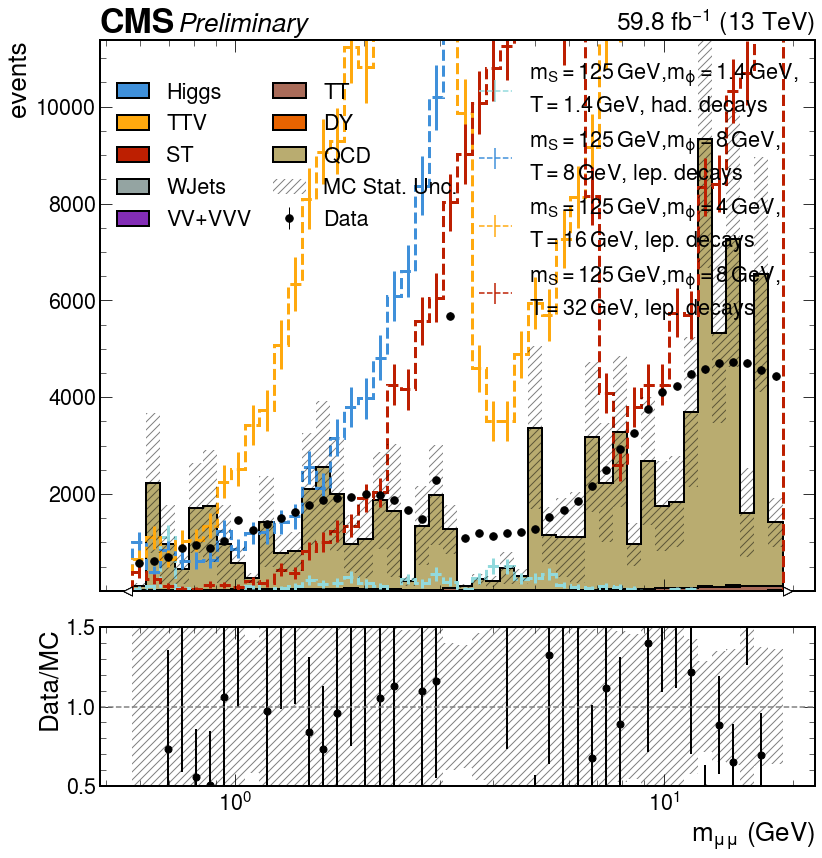

SR_high_temp_tight_dimuon_mass, nMuon=3

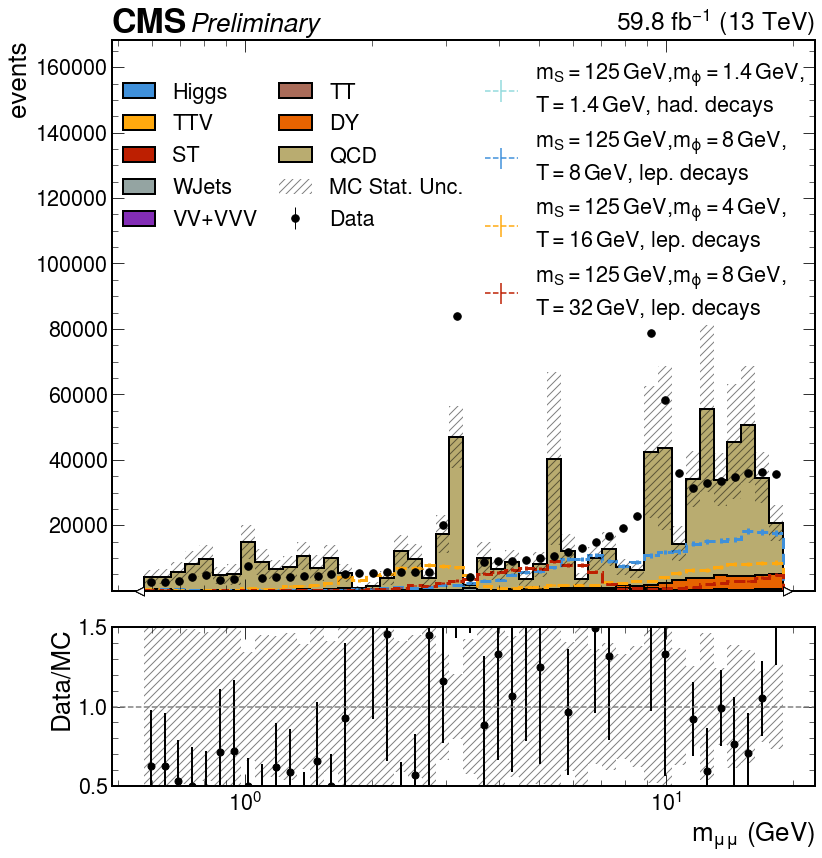

SR_high_temp_tight_dimuon_mass, nMuon=4

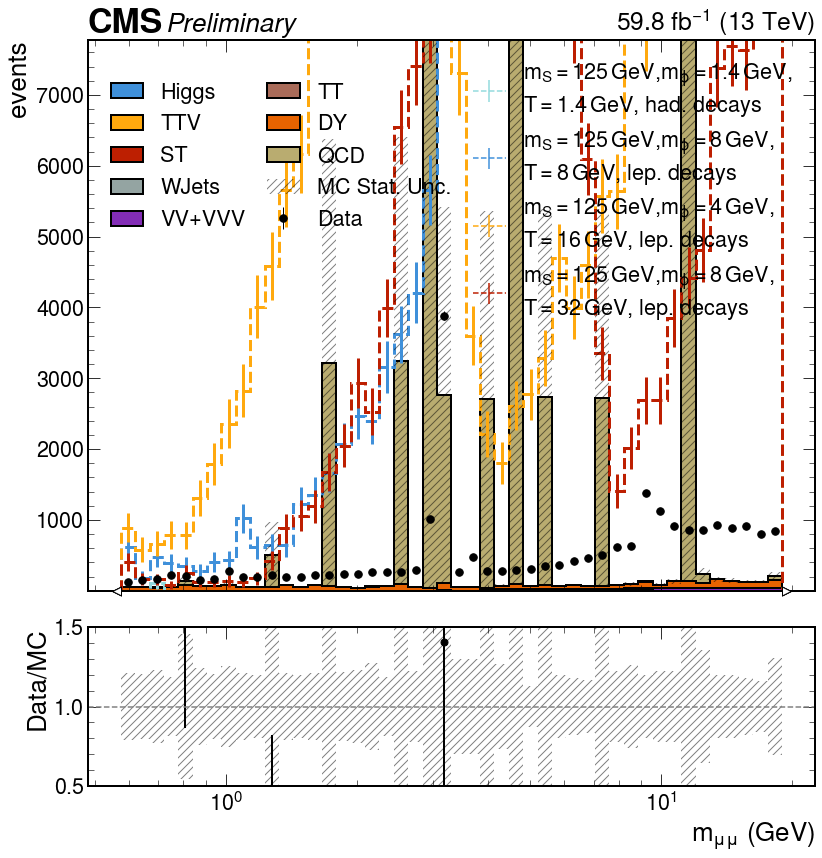

SR_high_temp_tight_dimuon_mass, nMuon=5

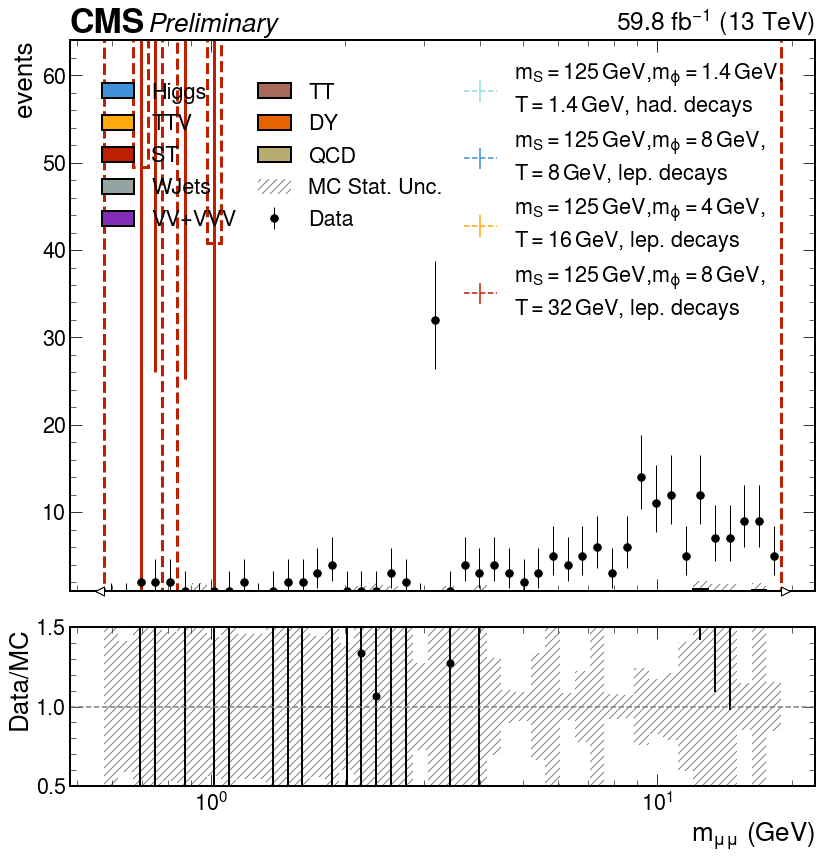

In [46]:
mc_processes = [
    ("Higgs_2018", "Higgs"),
    ("TTV_2018", "TTV"),
    ("ST_NLO_2018", "ST"),
    ("WJets_2018", "WJets"),
    ("VV+VVV_2018", "VV+VVV"),
    ("TT_powheg_2018", "TT"),
    ("DY_2018", "DY"),
    ("QCD_Pt_MuEnrichedPt5_2018", "QCD"),
]

signal_processes = [
    "GluGluToSUEP_mS125.000_mPhi1.400_T1.400_modehadronic_13TeV_2018",
    "GluGluToSUEP_mS125.000_mPhi8.000_T8.000_modeleptonic_13TeV_2018",
    "GluGluToSUEP_mS125.000_mPhi4.000_T16.000_modeleptonic_13TeV_2018",
    "GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018",
]
signal_labels = [
    r"$m_S=125\,$GeV,$m_\phi=1.4\,$GeV," + "\n" + r"$T=1.4\,$GeV, had. decays",
    r"$m_S=125\,$GeV,$m_\phi=8\,$GeV," + "\n" + r"$T=8\,$GeV, lep. decays",
    r"$m_S=125\,$GeV,$m_\phi=4\,$GeV," + "\n" + r"$T=16\,$GeV, lep. decays",
    r"$m_S=125\,$GeV,$m_\phi=8\,$GeV," + "\n" + r"$T=32\,$GeV, lep. decays",
]

mass_range = slice(0.6j, 20j, 1j)


def calculate_k_factor(
    plots,
    plot,
    cut=(slice(None), slice(None)),
    year="2018",
    process="QCD_Pt_MuEnrichedPt5",
):
    mc_processes = [
        "Higgs",
        "TTV",
        "ST_NLO",
        "WJets",
        "VV+VVV",
        "TT_powheg",
        "DY",
        "QCD_Pt_MuEnrichedPt5",
    ]

    if plots[f"{process}_{year}"][plot][cut].sum().value == 0:
        return 1

    tot_bkg = plots[f"{process}_{year}"][plot][cut].copy().reset()
    for mc_proc in mc_processes:
        if process == mc_proc:
            continue
        tot_bkg += plots[f"{mc_proc}_{year}"][plot][cut]
    k_factor = (
        plots["Data_" + year][plot][cut].sum().value - tot_bkg.sum().value
    ) / plots[f"{process}_{year}"][plot][cut].sum().value
    return k_factor


def plot_ratio(hist_data, hist_bkg_total, ax, x_hatch):
    ratio = np.divide(
        hist_data.values(),
        hist_bkg_total.values(),
        out=np.ones_like(hist_data.values()),
        where=hist_bkg_total.values() != 0,
    )
    ratio_err = np.where(
        hist_bkg_total.values() > 0,
        np.sqrt(
            (hist_bkg_total.values() ** -2) * (hist_data.variances())
            + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
            * (hist_bkg_total.variances())
        ),
        0,
    )
    ax.errorbar(
        hist_data.axes.centers[0],
        ratio,
        yerr=ratio_err,
        color="black",
        fmt="o",
        linestyle="none",
        markersize=7,
        lw=2,
    )

    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
    mc_rel_unc = np.divide(
        np.sqrt(hist_bkg_total.variances()),
        hist_bkg_total.values(),
        out=np.zeros_like(hist_bkg_total.values()),
        where=hist_bkg_total.values() != 0,
    )
    y_hatch2 = np.vstack(
        (np.ones_like(hist_bkg_total.values()), np.ones_like(hist_bkg_total.values()))
    ).reshape((-1,), order="F")
    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
    ax.fill_between(
        x=x_hatch,
        y1=y_hatch2 - y_hatch2_unc,
        y2=y_hatch2 + y_hatch2_unc,
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
    )
    ax.axhline(1, ls="--", color="gray")


for region in ["SR_low_temp", "SR_high_temp"]:
    for subregion in ["loose", "tight"]:
        for nMuon in range(3, 6):
            k_factor = calculate_k_factor(
                plots,
                f"{region}_{subregion}_dimuon_mass",
                cut=(slice(13j, None), nMuon * 1j),
            )

            print(f"{region}_{subregion}_dimuon_mass, {nMuon=}")
            hists_mc = []
            hist_bkg_total = (
                plots["QCD_Pt_MuEnrichedPt5_2018"][f"{region}_{subregion}_dimuon_mass"][
                    mass_range, nMuon * 1j
                ]
                .copy()
                .reset()
            )
            for process, label in mc_processes:
                h_mc = plots[process][f"{region}_{subregion}_dimuon_mass"][
                    mass_range, nMuon * 1j
                ]
                if process == "QCD_Pt_MuEnrichedPt5_2018":
                    h_mc *= k_factor
                hists_mc.append(h_mc)
                hist_bkg_total += h_mc.copy()

            hists_signal = []
            for process in signal_processes:
                h_signal = plots[process][f"{region}_{subregion}_dimuon_mass"][
                    mass_range, nMuon * 1j
                ]
                hists_signal.append(h_signal)

            # fig, ax1 = plt.subplots(figsize=(13, 12))
            fig = plt.figure(figsize=(12, 12.5))
            plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
            ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
            ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

            hep.histplot(
                hists_mc,
                yerr=[np.sqrt(h.variances()) for h in hists_mc],
                stack=True,
                label=[p[1] for p in mc_processes],
                histtype="fill",
                ec="black",
                lw=2,
                ax=ax1,
            )

            hep.histplot(
                plots[f"Data_2018"][f"{region}_{subregion}_dimuon_mass"][
                    mass_range, nMuon * 1j
                ],
                label=["Data"],
                histtype="errorbar",
                mec="black",
                mfc="black",
                ecolor="black",
                markersize=15,
                lw=3,
                ax=ax1,
            )

            x_hatch = np.vstack(
                (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
            ).reshape((-1,), order="F")
            y_hatch1 = np.vstack(
                (hist_bkg_total.values(), hist_bkg_total.values())
            ).reshape((-1,), order="F")
            y_hatch1_unc = np.vstack(
                (
                    np.sqrt(hist_bkg_total.variances()),
                    np.sqrt(hist_bkg_total.variances()),
                )
            ).reshape((-1,), order="F")
            ax1.fill_between(
                x=x_hatch,
                y1=y_hatch1 - y_hatch1_unc,  # type: ignore[assign]
                y2=y_hatch1 + y_hatch1_unc,  # type: ignore[assign]
                label="MC Stat. Unc.",
                step="pre",
                facecolor="none",
                edgecolor=(0, 0, 0, 0.5),
                linewidth=0,
                hatch="///",
                zorder=2,
            )
            hep.histplot(
                hists_signal,
                yerr=[np.sqrt(h.variances()) for h in hists_signal],
                label=[s for s in signal_labels],
                lw=3,
                ls="--",
                ax=ax1,
            )

            plot_ratio(
                plots[f"Data_{year}"][f"{region}_{subregion}_dimuon_mass"][
                    mass_range, nMuon * 1j
                ],
                hist_bkg_total,
                ax2,
                x_hatch,
            )

            hep.cms.label(llabel="Preliminary", data=True, lumi=59.8, ax=ax1)

            plt.sca(ax2)
            plt.xlabel(r"$m_{\mu\mu}$ (GeV)")
            plt.ylim(0.5, 1.5)
            plt.ylabel("Data/MC")
            plt.setp(ax1.get_xticklabels(), visible=False)
            ax1.set_xlabel("", visible=False)

            y_max_lin = 2 * max(
                plots[f"Data_{year}"][f"{region}_{subregion}_dimuon_mass"][
                    mass_range, nMuon * 1j
                ].values()
            )

            plt.sca(ax1)
            # plt.xlim(1e-1, 1e2)
            plt.ylim(1, y_max_lin)
            plt.xscale("log")
            # plt.yscale("log")
            plt.legend(ncol=3, loc="upper center", columnspacing=1)
            plt.ylabel("events")
            plt.tight_layout()
            plt.show()

In [45]:
plots["QCD_Pt_MuEnrichedPt5_2018"]["SR_high_temp_tight_dimuon_mass"][
    0.5j:15j, ::sum
].axes[0].edges

array([ 0.49341949,  0.53238597,  0.57442972,  0.61979376,  0.6687403 ,
        0.72155227,  0.77853492,  0.84001763,  0.90635576,  0.97793277,
        1.05516238,  1.13849099,  1.22840026,  1.32540986,  1.43008054,
        1.54301731,  1.66487295,  1.79635182,  1.93821388,  2.09127911,
        2.25643225,  2.43462792,  2.62689611,  2.83434817,  3.0581832 ,
        3.29969499,  3.56027954,  3.84144304,  4.14481068,  4.47213595,
        4.82531087,  5.20637682,  5.61753643,  6.06116627,  6.53983058,
        7.05629612,  7.61354813,  8.21480762,  8.86354997,  9.563525  ,
       10.31877867, 11.13367647, 12.01292864, 12.96161738, 13.98522627])

In [ ]:
(2.7, 3.6), (8.86, 11.13)